# Building a Customer Feedback Analysis System Using NLP

### Generate Dataset

In [1]:
import random
import pandas as pd
import os

# Define categories and sample phrases
categories = {
    "payment": {
        "positive": [
            "Payment successful instantly",
            "Payment process is seamless",
            "Payment confirmation received quickly",
            "Payment retry worked fine"
        ],
        "negative": [
            "Payment keeps failing",
            "Payment declined without reason",
            "Payment failed twice today",
            "Payment gateway error during checkout"
        ],
        "neutral": [
            "Payment process is okay",
            "Payment took some time",
            "Payment was completed eventually",
            "Payment experience was average"
        ]
    },
    "login": {
        "positive": [
            "Login works smoothly",
            "Login page loads instantly",
            "Login OTP arrived quickly",
            "Login process is simple"
        ],
        "negative": [
            "Login OTP is not arriving",
            "Login process is confusing",
            "Login OTP expired too soon",
            "Login failed multiple times"
        ],
        "neutral": [
            "Login process is acceptable",
            "Login took a while",
            "Login was neither fast nor slow",
            "Login experience was average"
        ]
    },
    "performance": {
        "positive": [
            "Application runs faster now",
            "Application performance improved after update",
            "Application is stable",
            "Application speed is acceptable"
        ],
        "negative": [
            "Application is very slow",
            "Application consumes too much battery",
            "Application update caused slowdown",
            "App freezes frequently"
        ],
        "neutral": [
            "Application performance is okay",
            "Application speed is average",
            "Application works fine sometimes",
            "Application response time is acceptable"
        ]
    },
    "support": {
        "positive": [
            "Support solved my issue quickly",
            "Support team was very helpful",
            "Support resolved issue in minutes",
            "Customer support was excellent"
        ],
        "negative": [
            "Support team did not respond",
            "Support agent was rude",
            "Support gave wrong information",
            "Support did not follow up"
        ],
        "neutral": [
            "Support experience was okay",
            "Support response was average",
            "Support interaction was acceptable",
            "Support took some time"
        ]
    },
    "ui": {
        "positive": [
            "UI looks clean and modern",
            "UI colors are attractive",
            "UI navigation is intuitive",
            "UI animations are smooth"
        ],
        "negative": [
            "UI is cluttered",
            "UI fonts are hard to read",
            "UI design is confusing",
            "UI layout is poor"
        ],
        "neutral": [
            "UI is acceptable",
            "UI looks fine",
            "UI experience was average",
            "UI is okay"
        ]
    },
    "bug": {
        "negative": [
            "Bug in notification system",
            "Bug in search functionality",
            "Bug in file upload",
            "App crashes frequently"
        ],
        "neutral": [
            "Minor bug reported",
            "Bug occurs occasionally",
            "Bug is not critical",
            "Bug was noticed"
        ]
    },
    "feature_request": {
        "neutral": [
            "Feature request: dark mode",
            "Feature request: export to PDF",
            "Feature request: voice commands",
            "Feature request: offline mode",
            "Feature request: multi-language support"
        ]
    }
}

# Generate dataset
data = []
for category, sentiments in categories.items():
    for sentiment, phrases in sentiments.items():
        for phrase in phrases:
            # Generate multiple variations by adding random endings
            for i in range(10):  # 10 variations per phrase
                variation = phrase
                if sentiment == "negative":
                    variation += random.choice(["", " again", " today", " frequently"])
                elif sentiment == "positive":
                    variation += random.choice(["", " without issues", " smoothly", " quickly"])
                else:
                    variation += random.choice(["", " overall", " sometimes", " generally"])
                data.append([variation, sentiment, category])

# Convert to DataFrame
df = pd.DataFrame(data, columns=["feedback", "sentiment", "category"])

# Limit to 500 entries
df = df.sample(500, random_state=42).reset_index(drop=True)

os.makedirs("../Dataset", exist_ok=True)
# Save to CSV
df.to_csv("../Dataset/feedback_dataset.csv", index=False)

print("Dataset generated with", len(df), "entries and saved as feedback_dataset.csv")


Dataset generated with 500 entries and saved as feedback_dataset.csv


### Load Dataset

In [2]:
df=pd.read_csv("../Dataset/feedback_dataset.csv")
df.head(10)

,feedback,sentiment,category
0,Support interaction was acceptable sometimes,neutral,support
1,Login OTP arrived quickly quickly,positive,login
2,Application update caused slowdown again,negative,performance
3,Application response time is acceptable,neutral,performance
4,UI animations are smooth quickly,positive,ui
5,Application is stable smoothly,positive,performance
6,Payment gateway error during checkout,negative,payment
7,Payment process is okay,neutral,payment
8,Login page loads instantly smoothly,positive,login
9,Application works fine sometimes generally,neutral,performance


### Text Cleaning

In [3]:
import re

# Cleaning function
def clean_text(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)  # normalize spaces
    text = re.sub(r"[^a-zA-Z0-9\s!?]", "", text)  # remove special chars except !?
    return text

# Apply cleaning to feedback column
df["clean_feedback"] = df["feedback"].apply(clean_text)


In [4]:
df[["feedback", "clean_feedback"]].head()

,feedback,clean_feedback
0,Support interaction was acceptable sometimes,support interaction was acceptable sometimes
1,Login OTP arrived quickly quickly,login otp arrived quickly quickly
2,Application update caused slowdown again,application update caused slowdown again
3,Application response time is acceptable,application response time is acceptable
4,UI animations are smooth quickly,ui animations are smooth quickly


### Tokenization

In [5]:
# Simple tokenization using Python split
def tokenize(text: str):
    return text.split()

# Apply tokenization to cleaned feedback
df["tokens"] = df["clean_feedback"].apply(tokenize)

In [6]:
df[["clean_feedback", "tokens"]].head()

,clean_feedback,tokens
0,support interaction was acceptable sometimes,"[support, interaction, was, acceptable, someti..."
1,login otp arrived quickly quickly,"[login, otp, arrived, quickly, quickly]"
2,application update caused slowdown again,"[application, update, caused, slowdown, again]"
3,application response time is acceptable,"[application, response, time, is, acceptable]"
4,ui animations are smooth quickly,"[ui, animations, are, smooth, quickly]"


### Stop Words Removal

In [7]:
import nltk
from nltk.corpus import stopwords

# Download stopwords 
nltk.download("stopwords")


# Define stop words (English)
stop_words = set(stopwords.words("english"))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# Apply stop word removal to tokenized column
df["tokens_no_stop"] = df["tokens"].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
df[["tokens", "tokens_no_stop"]].head()

,tokens,tokens_no_stop
0,"[support, interaction, was, acceptable, someti...","[support, interaction, acceptable, sometimes]"
1,"[login, otp, arrived, quickly, quickly]","[login, otp, arrived, quickly, quickly]"
2,"[application, update, caused, slowdown, again]","[application, update, caused, slowdown]"
3,"[application, response, time, is, acceptable]","[application, response, time, acceptable]"
4,"[ui, animations, are, smooth, quickly]","[ui, animations, smooth, quickly]"


### Stemming

In [9]:
from nltk.stem import PorterStemmer

# Initialize stemmer
stemmer = PorterStemmer()

# Function to apply stemming
def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]

# Apply stemming to stopword-removed tokens
df["tokens_stemmed"] = df["tokens_no_stop"].apply(stem_tokens)


In [10]:
df[["tokens_no_stop", "tokens_stemmed"]].head()

,tokens_no_stop,tokens_stemmed
0,"[support, interaction, acceptable, sometimes]","[support, interact, accept, sometim]"
1,"[login, otp, arrived, quickly, quickly]","[login, otp, arriv, quickli, quickli]"
2,"[application, update, caused, slowdown]","[applic, updat, caus, slowdown]"
3,"[application, response, time, acceptable]","[applic, respons, time, accept]"
4,"[ui, animations, smooth, quickly]","[ui, anim, smooth, quickli]"


### Lemmatization

In [11]:
import spacy

# download spaCy English model
spacy.cli.download("en_core_web_sm")

# Load spaCy English model 
nlp = spacy.load("en_core_web_sm")

# Function to lemmatize tokens
def lemmatize_text(text):
    doc = nlp(text)
    return [token.lemma_ for token in doc]

# Apply lemmatization to cleaned feedback
df["tokens_lemmatized"] = df["clean_feedback"].apply(lemmatize_text)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [12]:
df[["clean_feedback", "tokens_lemmatized"]].head()

,clean_feedback,tokens_lemmatized
0,support interaction was acceptable sometimes,"[support, interaction, be, acceptable, sometimes]"
1,login otp arrived quickly quickly,"[login, otp, arrive, quickly, quickly]"
2,application update caused slowdown again,"[application, update, cause, slowdown, again]"
3,application response time is acceptable,"[application, response, time, be, acceptable]"
4,ui animations are smooth quickly,"[ui, animation, be, smooth, quickly]"


### TF‑IDF Vectorization

In [13]:

from sklearn.feature_extraction.text import TfidfVectorizer

# Use the cleaned feedback column
texts = df["clean_feedback"].astype(str).tolist()

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(ngram_range=(1,2))  # unigrams + bigrams

# Fit and transform
X = vectorizer.fit_transform(texts)

print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
print("Shape of TF-IDF matrix:", X.shape)

# Example: show first row vector
print("First feedback:", texts[0])
print("TF-IDF vector:", X[0].toarray())


Vocabulary size: 469
Shape of TF-IDF matrix: (500, 469)
First feedback: support interaction was acceptable sometimes
TF-IDF vector: [[0.28678642 0.         0.         0.         0.         0.37728343
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.     

#### TF‑IDF Word Mapping for Entire Dataset

In [14]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer


# Use cleaned feedback column
texts = df["clean_feedback"].astype(str).tolist()

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(texts)

# Get vocabulary terms
features = vectorizer.get_feature_names_out()

# Function to show non-zero TF-IDF values for one feedback
def show_tfidf_for_feedback(index):
    row = X[index].toarray()[0]
    print(f"\nFeedback: {texts[index]}")
    for word, value in zip(features, row):
        if value > 0:
            print(f"{word}: {value:.4f}")

for i in range(3):
    show_tfidf_for_feedback(i)



Feedback: support interaction was acceptable sometimes
acceptable: 0.2868
acceptable sometimes: 0.3773
interaction: 0.3962
interaction was: 0.3962
sometimes: 0.2499
support: 0.2068
support interaction: 0.3962
was: 0.2059
was acceptable: 0.3962

Feedback: login otp arrived quickly quickly
arrived: 0.3698
arrived quickly: 0.3698
login: 0.2014
login otp: 0.3003
otp: 0.3003
otp arrived: 0.3698
quickly: 0.4817
quickly quickly: 0.3698

Feedback: application update caused slowdown again
again: 0.2319
application: 0.1973
application update: 0.3479
caused: 0.3479
caused slowdown: 0.3479
slowdown: 0.3479
slowdown again: 0.4522
update: 0.3125
update caused: 0.3479


### Sentiment Classification using LogisticRegression

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Features (cleaned feedback text)
X_texts = df["clean_feedback"].astype(str)

# Labels (sentiment column)
y = df["sentiment"]

# TF-IDF vectorization
vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(X_texts)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
model_sent = LogisticRegression(max_iter=1000)
model_sent.fit(X_train, y_train)



,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [16]:
# Predictions
y_pred = model_sent.predict(X_test)
print(y_pred[0:15])


['neutral' 'neutral' 'neutral' 'negative' 'neutral' 'negative' 'negative'
 'neutral' 'negative' 'neutral' 'neutral' 'negative' 'neutral' 'positive'
 'neutral']


In [17]:
# Example prediction
sample = ["Payment keeps failing again"]
sample_vec = vectorizer.transform(sample)
print("Sample prediction:", model_sent.predict(sample_vec)[0])


Sample prediction: negative


### Evaluation of Sentiment Classifier

In [18]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

    negative       1.00      1.00      1.00        36
     neutral       1.00      1.00      1.00        51
    positive       1.00      1.00      1.00        13

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



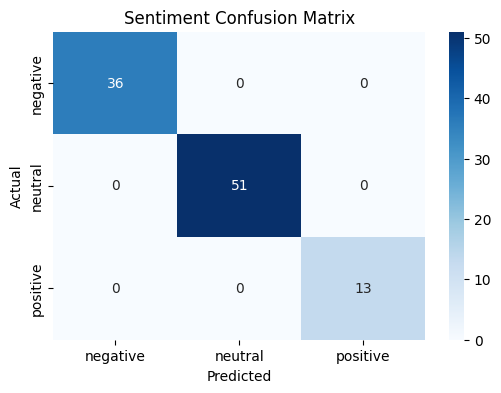

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model_sent.classes_,
            yticklabels=model_sent.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Confusion Matrix")
plt.show()


### Category Classification using LogisticRegression

In [21]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Features (cleaned feedback text)
X_texts = df["clean_feedback"].astype(str)

# Labels (category column)
y = df["category"]

# TF-IDF vectorization
vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(X_texts)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
model_cat = LogisticRegression(max_iter=1000)
model_cat.fit(X_train, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### Evaluation of Category Classifier

In [22]:
# Predictions
y_pred_cat = model_cat.predict(X_test)

print(y_pred_cat[0:15])

['performance' 'payment' 'performance' 'login' 'feature_request' 'payment'
 'login' 'feature_request' 'payment' 'support' 'performance' 'ui' 'bug'
 'performance' 'bug']


Classification Report:
                  precision    recall  f1-score   support

            bug       1.00      1.00      1.00        13
feature_request       1.00      1.00      1.00        12
          login       1.00      1.00      1.00        18
        payment       1.00      1.00      1.00        14
    performance       1.00      1.00      1.00        16
        support       1.00      1.00      1.00        14
             ui       1.00      1.00      1.00        13

       accuracy                           1.00       100
      macro avg       1.00      1.00      1.00       100
   weighted avg       1.00      1.00      1.00       100



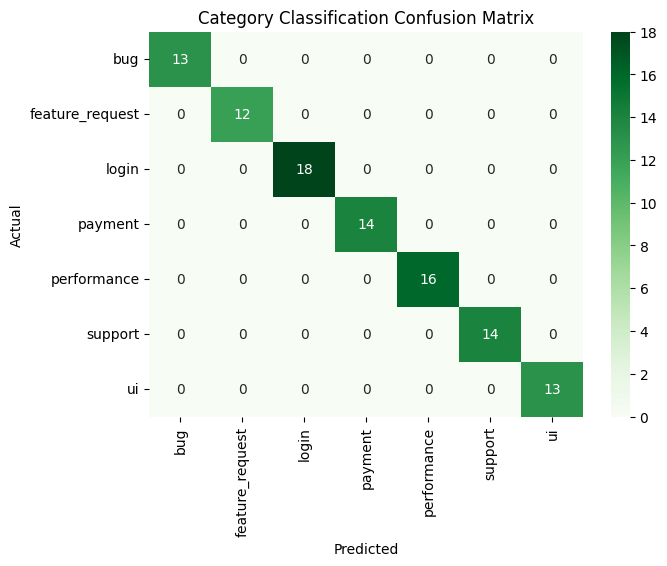

In [23]:

print("Classification Report:\n", classification_report(y_test, y_pred_cat))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_cat, labels=model_cat.classes_)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=model_cat.classes_,
            yticklabels=model_cat.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Category Classification Confusion Matrix")
plt.show()

In [24]:
# Example prediction
sample = ["Login OTP expired too soon"]
sample_vec = vectorizer.transform(sample)
print("Sample prediction:", model_cat.predict(sample_vec)[0])

Sample prediction: login


### Saving Models & Vectorizer

In [25]:
import joblib
import os

# Create models folder one level up (outside Notebook folder)
os.makedirs("../Models", exist_ok=True)

# Save sentiment model
joblib.dump(model_sent, "../Models/sentiment_model.pkl")

# Save category model
joblib.dump(model_cat, "../Models/category_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(vectorizer, "../Models/tfidf_vectorizer.pkl")

print("Models saved inside '../Models/' folder successfully!")


Models saved inside '../Models/' folder successfully!


In [2]:
import joblib

# Load models
model_sent = joblib.load("../Models/sentiment_model.pkl")
model_cat = joblib.load("../Models/category_model.pkl")
vectorizer = joblib.load("../Models/tfidf_vectorizer.pkl")

# Predict
sample = ["Payment keeps failing again"]
sample_vec = vectorizer.transform(sample)
print("Sentiment:", model_sent.predict(sample_vec)[0])
print("Category:", model_cat.predict(sample_vec)[0])


Sentiment: negative
Category: payment
